<center>
<img src="https://raw.githubusercontent.com/FUlyankin/r_probability/master/end_seminars_2020/sem08/real_expect.png" width="800">

# Домашнее задание 3: Аварии на шахтах
</center>

## Общая информация

__Дата выдачи:__ 14.03.2026

__Дедлайн:__ 23:59MSK 05.04.2026

In [37]:
import numpy as np

import scipy.stats as sts
import matplotlib.pyplot as plt
from math import factorial

plt.style.use('ggplot')  # стиль для графиков
%matplotlib inline

На угольных шахтах ежегодно происходят аварии. Англия довольно давно собирает информацию о числе крупных аварий. Именно её нам предстоит проанализировать:

* хочется понять как часто в среднем происходят аварии 
* насколько большой у среднего числа аварий доверительный интервал

In [38]:
import pandas as pd

df = pd.read_csv("coals.csv", index_col=0)
df.head()

,year,count
1,1851,4
2,1852,5
3,1853,4
4,1854,1
5,1855,0


В колонке `year` находится год наблюдений. В колонке `count` число аварий за этот год на шахтах в Англии. Посмотрим на распределение числа аварий. 

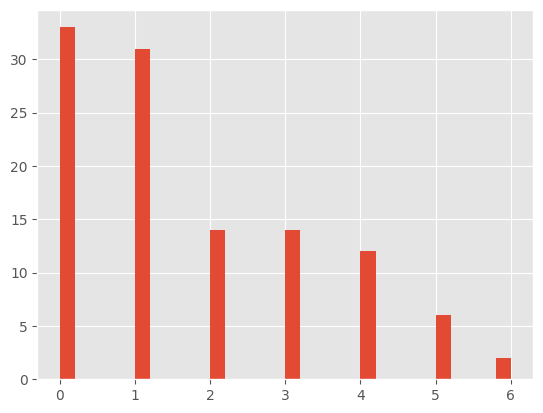

In [39]:
df['count'].hist(bins=30);

Судя по гистограмме уместно предположить, что число аварий имеет распределение Пуассона, $Poiss(\lambda)$.  То есть, если мы хотим что-то понять про среднее число аварий, нам надо оценить параметр $\lambda$. 

__а) Метод моментов__

Найдите оценку параметра $\lambda$ с помощью метода моментов. Запишите получившийся результат в переменную `lambda_hat`.

In [40]:
# your code here
def momentpoiss(df):
    return df['count'].sum()/n_hat

n_hat = df.shape[0]   # число наблюдений 
lam_hat = momentpoiss(df)        # ваша оценка метода моментов
print(lam_hat)


1.7053571428571428


__б) Стандартное отклонение__ 

Среднее, оценённое методом моментов будет иметь асимптотически нормальное распределение. Оцените стандартное отклонение этого распределения по выборке и запишите ответ в переменную `lam_se`. 

> __Примечание:__ мы предполагаем, что выборка пришла из распределения Пуассона. Для него $Var(X) = \lambda$. Для оценки стандартного отклонения используйте этот факт. Конечно же вы можете оценить его через функцию `std`, в плане асимптотики результат получится одинаковый. Оба способа корректны. Но с точки зрения грейдера, у вас будет ошибка. 

In [41]:
# your code here
def self_std(lam_hat, n_hat):
    return np.sqrt(lam_hat / n_hat)
    
lam_se = self_std(lam_hat, n_hat)      # ваша оценка

print(lam_se)

0.1233953121525469


__в) Доверительный интервал__ 

Постройте для неизвестного математического ожидания $\lambda$ доверительный интервал. Возьмите уровень значимости равный $10\%$. В переменные `left` и `right` запишите соотвествующие границы интервала. В переменную `delta` запишите его ширину.

In [42]:
# your code here
alpha = 0.1

z_stat = sts.norm.ppf(1 - alpha/2)

left = lam_hat - z_stat*lam_se
right = lam_hat + z_stat*lam_se
delta = right - left
print(delta)

0.4059344534858518


__г) Число катастроф__  

Многие говорят, что в $20$ веке катастроф стало на порядок меньше. Давайте проверим это. Постройте оценку для $\lambda_1$ по данным до $1900$ года включительно. Постройте оценку для $\lambda_2$ по данным после $1900$ года. Для разности $\lambda_1 - \lambda_2$ постройте $95\%$ доверительный интервал. 

In [43]:
def momentpoissX(x):
    return x.sum()/len(x)

x = df[df.year <= 1900]['count']
y = df[df.year > 1900]['count']

alpha = 0.05

lam_less_1900 = momentpoissX(x)
lam_more_1900 = momentpoissX(y)

lam_se_less_1900 = self_std(lam_less_1900, len(x))     
lam_se_more_1900 = self_std(lam_more_1900, len(y))     

z_stat= sts.norm.ppf(1 - alpha/2)

diff = lam_less_1900 - lam_more_1900
se_diff = np.sqrt(lam_se_less_1900**2 + lam_se_more_1900**2)

left = diff - z_stat * se_diff
right = diff + z_stat * se_diff
delta = right-left
print(left)
print(right)
print(delta)

# your code here


1.2835473859716393
2.3100010011251353
1.026453615153496


Ноль не вошёл в этот доверительный интервал. Это означает, что на уровне значимости $5\%$ мы можем сказать, что число аварий правда снизилось. 

__д) Вероятность для распределения Пуассона__ 

Вспомните формулу, по которой считается вероятность того, что Пуассоновская случайная величина примет какое-то значение. Найдите точечную оценку вероятности того, что произойдёт только одна авария. В качестве $\lambda$ используйте оценку метода моментов, полученную в первом задании. 

In [44]:
# your code here
def poiss_prob(k):
    return np.exp(-lam_hat) * (lam_hat ** k) / factorial(k)

print(poiss_prob(1))

0.3098761473208731


__е) Дельта-метод__ 

Та вероятность, которую мы нашли в предыдущем пункте - это лишь точечная оценка. Она является функцией от среднего. С помощью дельта-метода постройте для этой вероятности $95\%$ довертельный интервал.

In [45]:
def proizv(lam_hat):
    return np.exp(-lam_hat) - lam_hat*np.exp(-lam_hat)
    
alpha = 0.05

lam_se_proizv = abs(proizv(lam_hat))*lam_se
z_stat= sts.norm.ppf(1 - alpha/2)

left = poiss_prob(1) - z_stat * lam_se_proizv
right = poiss_prob(1) + z_stat * lam_se_proizv
delta = right-left

print(left)
print(right)
print(delta)
# your code here


0.27887850777625484
0.34087378686549136
0.06199527908923652


По аналогии можно построить доверительные интервалы для вероятности того, что случайная величина примет значения от нуля до девяти. Проделайте это в качестве необязательного упражнения и оформите процедуру расчёта в виде функции.

In [46]:
def prob_ci(k, alpha = 0.01, lam_hat=lam_hat,):
    poiss_prob1 = np.exp(-lam_hat) * (lam_hat ** k) / factorial(k)
    proizv = (np.exp(-lam_hat) * lam_hat**(k-1) / factorial(k)) * (k - lam_hat)
    print(lam_se)
    se_p_hat = abs(proizv) * lam_se

    z_stat = sts.norm.ppf(1 - alpha / 2)

    left = poiss_prob1 - z_stat * se_p_hat
    right = poiss_prob1 + z_stat * se_p_hat

    return left, right
# your code here


In [47]:
left, right = prob_ci(1)
delta = right - left

assert np.abs(delta - 0.08147) < 1e-5

left, right = prob_ci(0)
delta = right - left

assert np.abs(delta - 0.11551) < 1e-5

0.1233953121525469
0.1233953121525469


Сделали функцию? Запускайте код для не очень информативной картинки!

0.1233953121525469
0.1233953121525469
0.1233953121525469
0.1233953121525469
0.1233953121525469
0.1233953121525469
0.1233953121525469
0.1233953121525469
0.1233953121525469
0.1233953121525469


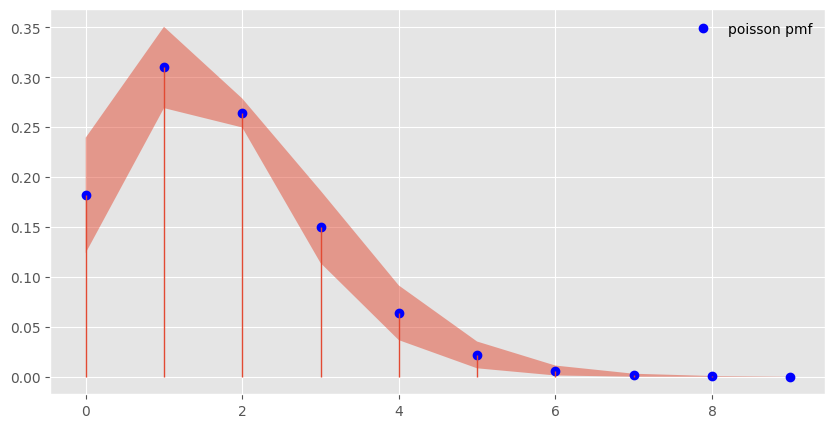

In [48]:
poiss_rv = sts.poisson(lam_hat)

x_list = np.arange(10)

p = []
left = []
right = []

for x in x_list:
    p_val = poiss_rv.pmf(x)
    left_val, right_val = prob_ci(x)
    p.append(p_val)
    left.append(left_val)
    right.append(right_val)

left = np.array(left)
right = np.array(right)
p = np.array(p)

plt.figure(figsize=(10,5))
plt.plot(x_list, p, 'bo', ms=6, label='poisson pmf')
plt.fill_between(x_list, left, right, alpha=0.5)
plt.vlines(x_list, 0, p, lw=1)
plt.legend(loc='best', frameon=False)
plt.show()

In [49]:
for k,(i,j) in enumerate(zip(left, right)):
    print(f"Вероятность P(X={k}) лежит между  {i:.5} и {j:.5}")

Вероятность P(X=0) лежит между  0.12395 и 0.23946
Вероятность P(X=1) лежит между  0.26914 и 0.35061
Вероятность P(X=2) лежит между  0.24971 и 0.27873
Вероятность P(X=3) лежит между  0.11396 и 0.18644
Вероятность P(X=4) лежит между  0.036649 и 0.091422
Вероятность P(X=5) лежит между  0.0084293 и 0.035252
Вероятность P(X=6) лежит между  0.0012388 и 0.011177
Вероятность P(X=7) лежит между  1.9936e-05 и 0.0030047
Вероятность P(X=8) лежит между  -5.5837e-05 и 0.00070061
Вероятность P(X=9) лежит между  -2.1966e-05 и 0.00014414


Интервалы получился довольно короткими. Попробуйте поиграться с уровнем значимости и посмотреть как они меняются в зависимости от него. 

В этой терадке нам осталось обсудить последний нюанс. Мы из теории вероятностей знаем, что для случайной величины $X$, имеющей распределение Пуассона $\mathbb{E}(X) = Var(X) = \lambda$. Для текущей выборки мы видим, что между дисперсией и средним есть небольшое отличие. 

In [50]:
df['count'].mean()

np.float64(1.7053571428571428)

In [51]:
df['count'].var()

np.float64(2.714205276705277)

Не факт, что мы имеем право предполагать, что наша выборка пришла к нам из распределения Пуассона. Все предпосылки о распределениях выборки нужно тестировать. Позже мы научимся это делать.